Image Classification Model using the MNIST dataset

In [12]:
# Import basic libraries
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine Learning libraries
from sklearn.metrics import confusion_matrix, classification_report

# Import Neural Networks Libraries
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings("ignore")

In [13]:
# Load the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [14]:
# View data
print(f"X-train Shape: ", X_train.shape)
print(f"y-train Shape: ", y_train.shape)
print(f"X-test Shape: ", X_test.shape)
print(f"y-test Shape: ", y_test.shape)

X-train Shape:  (60000, 28, 28)
y-train Shape:  (60000,)
X-test Shape:  (10000, 28, 28)
y-test Shape:  (10000,)


In [28]:
# Check the first image
# X_train

Data Preprocessing

In [16]:
# Perform Normalization
X_train = X_train / 255.0
X_test = X_test / 255.0

In [17]:
# Performing One hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

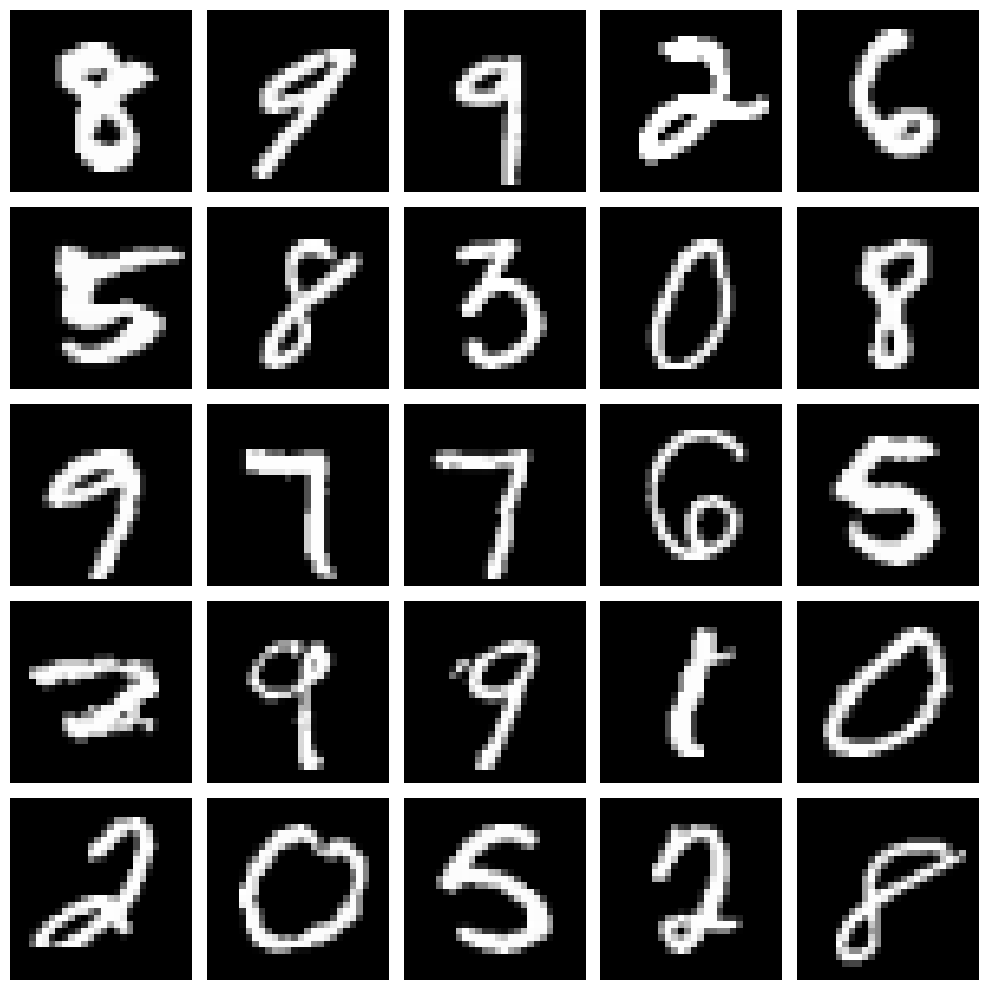

In [18]:
# Plot random digits from MNIST dataset
# np.random.seed(42)
selected_digits = np.random.choice(60000, 25)

fig, ax = plt.subplots(5,5, figsize=(10, 10))
for i in range(25):
    ax[i//5, i%5].imshow(X_train[selected_digits[i]], cmap='gray')
    ax[i//5, i%5].axis('off')
plt.tight_layout()
plt.show();

In [19]:
# Build Neural Networks Model
model = Sequential(
    [
        Flatten(input_shape=(28,28)),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(10, activation="softmax")
    ]
)

In [20]:
# Specify the optimizer and loss function
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [21]:
# Train the model
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7088 - loss: 0.9270 - val_accuracy: 0.9425 - val_loss: 0.1998
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9204 - loss: 0.2740 - val_accuracy: 0.9602 - val_loss: 0.1393
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9385 - loss: 0.2061 - val_accuracy: 0.9635 - val_loss: 0.1246
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9510 - loss: 0.1690 - val_accuracy: 0.9678 - val_loss: 0.1103
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9555 - loss: 0.1495 - val_accuracy: 0.9694 - val_loss: 0.1043
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9626 - loss: 0.1264 - val_accuracy: 0.9716 - val_loss: 0.0955
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9639 - loss: 0.1232 - val_accuracy: 0.9700 - val_loss: 0.0963
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9671 - loss: 0.1084 - val_accuracy: 0.

The model accuracy increased with a decrease in loss. The validation accuracy increased with a decrease in the validation loss, with the `10th` epoch closing with the validation accuracy of `0.9758`.
Thus, the model performed well on generalized data

In [22]:
# Evaluate the test model
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
# print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9714 - loss: 0.0984
Test Accuracy: 0.9761


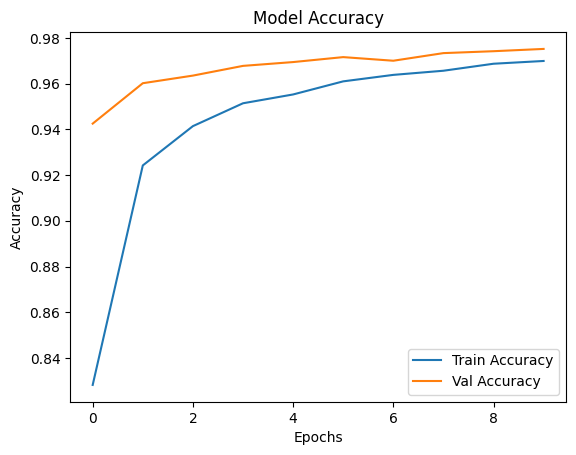

In [23]:
# Visualize training history
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show();

The model performed well on `validation data` with an accuracy of `0.97` meaning the model performed well on generalized data.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


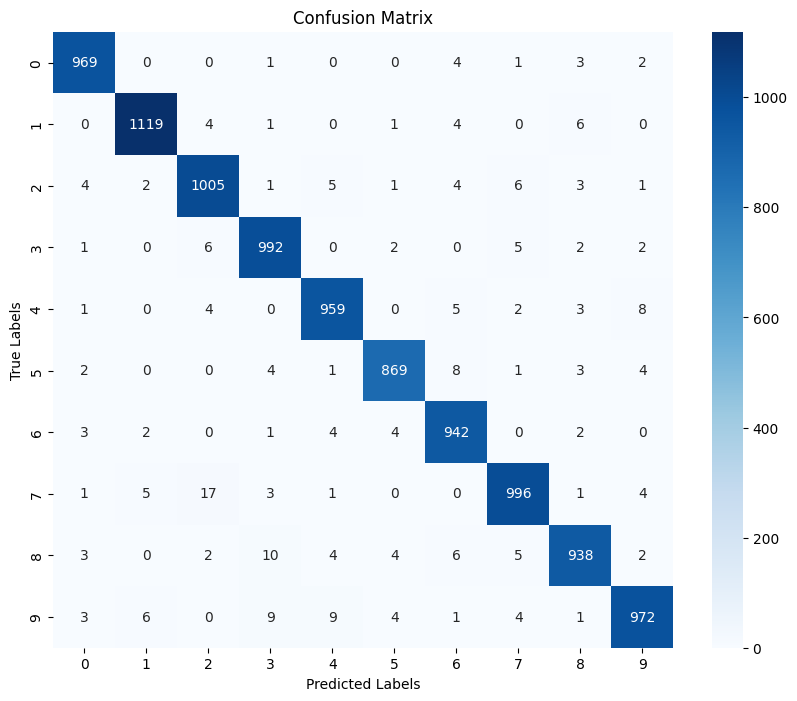

In [24]:
# Confusion matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show();

In [25]:
# Classification Report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.97      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.98      0.96      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [26]:
# Save and reload the model
model.save("mnist_ann_model.keras")

#  `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`

In [27]:
from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_ann_model.keras")
loaded_model.evaluate(X_test, y_test_cat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9714 - loss: 0.0984


[0.08543197065591812, 0.9761000275611877]